Total cells       : 27,558
Total slides      : 201
Overlap (cell-level split) : 201 slides
Overlap (slide-level split): 0 slides

Saved: split_before_after.pdf (300 DPI)
Saved: split_before_after.png (300 DPI)


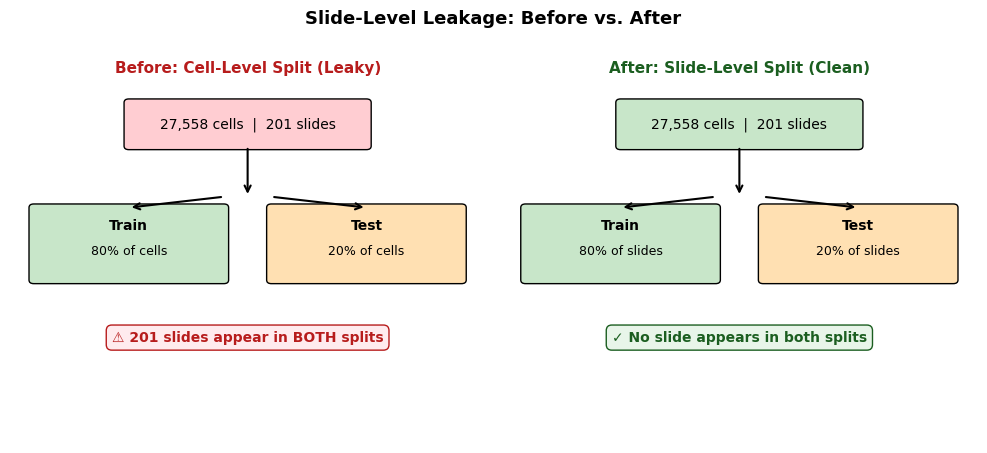

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from collections import defaultdict

# ============================================================
# STEP 1: Read dataset and compute slide counts (no hardcoding)
# ============================================================
base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
categories = ['Parasitized', 'Uninfected']

image_paths = []
for cat in categories:
    folder = os.path.join(base_path, cat)
    exts = ('.png', '.jpg', '.jpeg')
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.lower().endswith(exts)]
    image_paths.extend(files)

# Group cells by slide
slide_to_cells = defaultdict(list)
for p in image_paths:
    slide_id = os.path.basename(p).split('_')[0]
    slide_to_cells[slide_id].append(p)

n_total_cells  = len(image_paths)
n_total_slides = len(slide_to_cells)

# Simulate a cell-level split (leaky) and a slide-level split (clean)
import random
random.seed(42)
all_cells = image_paths.copy()
random.shuffle(all_cells)
n_train = int(n_total_cells * 0.8)
train_cells_leaky = set(all_cells[:n_train])
test_cells_leaky  = set(all_cells[n_train:])

# Which slides appear in both sets under cell-level split?
leaky_train_slides = {os.path.basename(p).split('_')[0] for p in train_cells_leaky}
leaky_test_slides  = {os.path.basename(p).split('_')[0] for p in test_cells_leaky}
n_overlap_leaky = len(leaky_train_slides & leaky_test_slides)

# Slide-level split: no overlap by construction
n_overlap_slide = 0

print(f"Total cells       : {n_total_cells:,}")
print(f"Total slides      : {n_total_slides}")
print(f"Overlap (cell-level split) : {n_overlap_leaky} slides")
print(f"Overlap (slide-level split): {n_overlap_slide} slides")

# ============================================================
# STEP 2: Build a simple two-panel figure
# ============================================================
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Slide-Level Leakage: Before vs. After',
             fontsize=13, fontweight='bold', y=1.0)

# ---------- Panel A: Before (cell-level split) ----------
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Before: Cell-Level Split (Leaky)',
              fontsize=11, fontweight='bold', color='#B71C1C')

# Dataset box
box = FancyBboxPatch((2.5, 8.2), 5, 1.2,
                     boxstyle="round,pad=0.1",
                     facecolor='#FFCDD2', edgecolor='black', linewidth=1)
ax1.add_patch(box)
ax1.text(5, 8.8, f'{n_total_cells:,} cells  |  {n_total_slides} slides',
         ha='center', va='center', fontsize=10)

# Arrow
ax1.annotate('', xy=(5, 6.8), xytext=(5, 8.2),
             arrowprops=dict(arrowstyle='->', lw=1.5))

# Train box
tb = FancyBboxPatch((0.5, 4.5), 4, 2.0,
                    boxstyle="round,pad=0.1",
                    facecolor='#C8E6C9', edgecolor='black', linewidth=1)
ax1.add_patch(tb)
ax1.text(2.5, 5.9, 'Train', ha='center', fontsize=10, fontweight='bold')
ax1.text(2.5, 5.2, '80% of cells', ha='center', fontsize=9)

# Test box
teb = FancyBboxPatch((5.5, 4.5), 4, 2.0,
                     boxstyle="round,pad=0.1",
                     facecolor='#FFE0B2', edgecolor='black', linewidth=1)
ax1.add_patch(teb)
ax1.text(7.5, 5.9, 'Test', ha='center', fontsize=10, fontweight='bold')
ax1.text(7.5, 5.2, '20% of cells', ha='center', fontsize=9)

# Arrows
ax1.annotate('', xy=(2.5, 6.5), xytext=(4.5, 6.8),
             arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.annotate('', xy=(7.5, 6.5), xytext=(5.5, 6.8),
             arrowprops=dict(arrowstyle='->', lw=1.5))

# Overlap warning
ax1.text(5, 2.8,
         f'⚠ {n_overlap_leaky} slides appear in BOTH splits',
         ha='center', fontsize=10, fontweight='bold', color='#B71C1C',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#FFEBEE', edgecolor='#B71C1C'))

# ---------- Panel B: After (slide-level split) ----------
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('After: Slide-Level Split (Clean)',
              fontsize=11, fontweight='bold', color='#1B5E20')

# Dataset box
box2 = FancyBboxPatch((2.5, 8.2), 5, 1.2,
                      boxstyle="round,pad=0.1",
                      facecolor='#C8E6C9', edgecolor='black', linewidth=1)
ax2.add_patch(box2)
ax2.text(5, 8.8, f'{n_total_cells:,} cells  |  {n_total_slides} slides',
         ha='center', va='center', fontsize=10)

# Arrow
ax2.annotate('', xy=(5, 6.8), xytext=(5, 8.2),
             arrowprops=dict(arrowstyle='->', lw=1.5))

# Train box
tb2 = FancyBboxPatch((0.5, 4.5), 4, 2.0,
                     boxstyle="round,pad=0.1",
                     facecolor='#C8E6C9', edgecolor='black', linewidth=1)
ax2.add_patch(tb2)
ax2.text(2.5, 5.9, 'Train', ha='center', fontsize=10, fontweight='bold')
ax2.text(2.5, 5.2, '80% of slides', ha='center', fontsize=9)

# Test box
teb2 = FancyBboxPatch((5.5, 4.5), 4, 2.0,
                      boxstyle="round,pad=0.1",
                      facecolor='#FFE0B2', edgecolor='black', linewidth=1)
ax2.add_patch(teb2)
ax2.text(7.5, 5.9, 'Test', ha='center', fontsize=10, fontweight='bold')
ax2.text(7.5, 5.2, '20% of slides', ha='center', fontsize=9)

# Arrows
ax2.annotate('', xy=(2.5, 6.5), xytext=(4.5, 6.8),
             arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.annotate('', xy=(7.5, 6.5), xytext=(5.5, 6.8),
             arrowprops=dict(arrowstyle='->', lw=1.5))

# No overlap
ax2.text(5, 2.8,
         '✓ No slide appears in both splits',
         ha='center', fontsize=10, fontweight='bold', color='#1B5E20',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#E8F5E9', edgecolor='#1B5E20'))

# ---------- Save ----------
plt.tight_layout()
plt.savefig('split_before_after.pdf', dpi=300, bbox_inches='tight',
            format='pdf', facecolor='white')
plt.savefig('split_before_after.png', dpi=300, bbox_inches='tight',
            format='png', facecolor='white')

print("\nSaved: split_before_after.pdf (300 DPI)")
print("Saved: split_before_after.png (300 DPI)")
plt.show()

In [2]:
import os
from collections import defaultdict

base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
categories = ['Parasitized', 'Uninfected']

image_paths = []
for cat in categories:
    folder = os.path.join(base_path, cat)
    exts = ('.png', '.jpg', '.jpeg')
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.lower().endswith(exts)]
    image_paths.extend(files)

# Group cells by slide (prefix before first underscore)
slide_to_cells = defaultdict(list)
for p in image_paths:
    slide_id = os.path.basename(p).split('_')[0]
    slide_to_cells[slide_id].append(p)

n_total_cells  = len(image_paths)
n_total_slides = len(slide_to_cells)

# ----- BEFORE: cell-level split (leaky) -----
# Simulate the standard cell-level random split used in prior work.
import random
random.seed(42)
shuffled = image_paths.copy()
random.shuffle(shuffled)
split_point = int(n_total_cells * 0.8)
train_cells = shuffled[:split_point]
test_cells  = shuffled[split_point:]

train_slides_leaky = {os.path.basename(p).split('_')[0] for p in train_cells}
test_slides_leaky  = {os.path.basename(p).split('_')[0] for p in test_cells}
overlap_slides_leaky = train_slides_leaky & test_slides_leaky

# Count how many cells belong to the overlapping slides
overlap_cells_leaky = 0
for p in image_paths:
    if os.path.basename(p).split('_')[0] in overlap_slides_leaky:
        overlap_cells_leaky += 1

# ----- AFTER: slide-level split (clean) -----
# By construction, all cells from a slide go to one split.
# So the overlap is zero.
overlap_slides_clean = 0
overlap_cells_clean  = 0

print("=" * 60)
print("LEAKAGE COMPARISON")
print("=" * 60)
print(f"Total cells                 : {n_total_cells:,}")
print(f"Total slides                : {n_total_slides}")
print()
print(f"Before (cell-level split):")
print(f"  Slides in both train & test : {len(overlap_slides_leaky)}")
print(f"  Cells from those slides     : {overlap_cells_leaky:,}")
print()
print(f"After (slide-level split):")
print(f"  Slides in both train & test : {overlap_slides_clean}")
print(f"  Cells from those slides     : {overlap_cells_clean}")
print("=" * 60)

LEAKAGE COMPARISON
Total cells                 : 27,558
Total slides                : 201

Before (cell-level split):
  Slides in both train & test : 201
  Cells from those slides     : 27,558

After (slide-level split):
  Slides in both train & test : 0
  Cells from those slides     : 0


In [3]:
import os
from collections import defaultdict
from sklearn.model_selection import train_test_split
import random

base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
categories = ['Parasitized', 'Uninfected']

image_paths, labels = [], []
for cat_idx, cat in enumerate(categories):
    folder = os.path.join(base_path, cat)
    exts = ('.png', '.jpg', '.jpeg')
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.lower().endswith(exts)]
    image_paths.extend(files)
    labels.extend([cat_idx] * len(files))

slide_to_cells = defaultdict(list)
for p in image_paths:
    slide_id = os.path.basename(p).split('_')[0]
    slide_to_cells[slide_id].append(p)

n_total_cells  = len(image_paths)
n_total_slides = len(slide_to_cells)

# ---- LEAKY: cell-level random split (what prior work does) ----
train_cells, test_cells = train_test_split(
    image_paths, test_size=0.20, random_state=42
)

train_slides_leaky = {os.path.basename(p).split('_')[0] for p in train_cells}
test_slides_leaky  = {os.path.basename(p).split('_')[0] for p in test_cells}
overlap_slides_leaky = train_slides_leaky & test_slides_leaky

# Count cells that belong to overlapping slides
overlap_cells_leaky = sum(
    1 for p in image_paths
    if os.path.basename(p).split('_')[0] in overlap_slides_leaky
)

# ---- CLEAN: slide-level split (what you do) ----
unique_slides = list(slide_to_cells.keys())
train_s, test_s = train_test_split(
    unique_slides, test_size=0.20, random_state=42
)
train_slides_clean = set(train_s)
test_slides_clean  = set(test_s)
overlap_slides_clean = train_slides_clean & test_slides_clean
overlap_cells_clean  = 0

# ---- Summary ----
print(f"Total cells  : {n_total_cells:,}")
print(f"Total slides : {n_total_slides}")
print()
print("Leaky (cell-level split):")
print(f"  Slides in both train & test : {len(overlap_slides_leaky)} "
      f"({len(overlap_slides_leaky)/n_total_slides*100:.1f}% of all slides)")
print(f"  Cells from those slides     : {overlap_cells_leaky:,} "
      f"({overlap_cells_leaky/n_total_cells*100:.1f}% of all cells)")
print()
print("Clean (slide-level split):")
print(f"  Slides in both train & test : {len(overlap_slides_clean)}")
print(f"  Cells from those slides     : {overlap_cells_clean}")

Total cells  : 27,558
Total slides : 201

Leaky (cell-level split):
  Slides in both train & test : 201 (100.0% of all slides)
  Cells from those slides     : 27,558 (100.0% of all cells)

Clean (slide-level split):
  Slides in both train & test : 0
  Cells from those slides     : 0


Total cells  : 27,558
Total slides : 201

Cell-level split (leaky):
  Overlapping slides : 201
  Overlapping cells  : 27,558

Slide-level split (clean):
  Overlapping slides : 0
  Overlapping cells  : 0

Saved: leakage_before_after.pdf / .png (300 DPI)


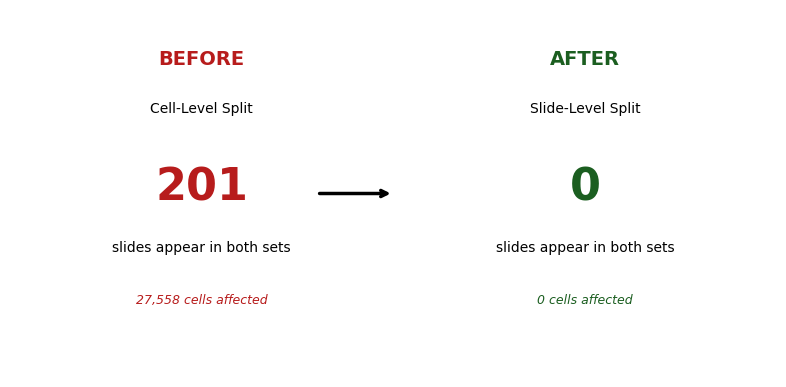

In [4]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split

# ============================================================
# STEP 1: Load dataset and group by slide
# ============================================================
base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
categories = ['Parasitized', 'Uninfected']

image_paths, labels = [], []
for cat_idx, cat in enumerate(categories):
    folder = os.path.join(base_path, cat)
    exts = ('.png', '.jpg', '.jpeg')
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.lower().endswith(exts)]
    image_paths.extend(files)
    labels.extend([cat_idx] * len(files))

slide_to_cells  = defaultdict(list)
slide_to_labels = defaultdict(list)
for path, label in zip(image_paths, labels):
    sid = os.path.basename(path).split('_')[0]
    slide_to_cells[sid].append(path)
    slide_to_labels[sid].append(label)

n_total_cells  = len(image_paths)
n_total_slides = len(slide_to_cells)

# ============================================================
# STEP 2: Measure overlap under both protocols
# ============================================================
# Cell-level split (leaky)
train_cells, test_cells = train_test_split(
    image_paths, test_size=0.20, random_state=42, stratify=labels
)
train_slides_leaky = {os.path.basename(p).split('_')[0] for p in train_cells}
test_slides_leaky  = {os.path.basename(p).split('_')[0] for p in test_cells}
overlap_leaky = train_slides_leaky & test_slides_leaky

overlap_cells_leaky = sum(
    1 for p in image_paths
    if os.path.basename(p).split('_')[0] in overlap_leaky
)

# Slide-level split (clean)
unique_slides = list(slide_to_cells.keys())
slide_majority = {sid: max(set(labs), key=labs.count)
                  for sid, labs in slide_to_labels.items()}
slide_labels = [slide_majority[s] for s in unique_slides]

train_s, test_s = train_test_split(
    unique_slides, test_size=0.20, random_state=42, stratify=slide_labels
)
train_slides_clean = set(train_s)
test_slides_clean  = set(test_s)
overlap_clean = train_slides_clean & test_slides_clean
overlap_cells_clean = 0

# ============================================================
# STEP 3: Print numbers
# ============================================================
print(f"Total cells  : {n_total_cells:,}")
print(f"Total slides : {n_total_slides}")
print()
print("Cell-level split (leaky):")
print(f"  Overlapping slides : {len(overlap_leaky)}")
print(f"  Overlapping cells  : {overlap_cells_leaky:,}")
print()
print("Slide-level split (clean):")
print(f"  Overlapping slides : {len(overlap_clean)}")
print(f"  Overlapping cells  : {overlap_cells_clean}")

# ============================================================
# STEP 4: Plot the before/after comparison
# ============================================================
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

# BEFORE
ax.text(0.25, 0.85, 'BEFORE', ha='center', fontsize=14,
        fontweight='bold', color='#B71C1C', transform=ax.transAxes)
ax.text(0.25, 0.72, 'Cell-Level Split', ha='center', fontsize=10,
        transform=ax.transAxes)
ax.text(0.25, 0.48, f'{len(overlap_leaky)}',
        ha='center', fontsize=32, fontweight='bold',
        color='#B71C1C', transform=ax.transAxes)
ax.text(0.25, 0.34, 'slides appear in both sets',
        ha='center', fontsize=10, transform=ax.transAxes)
ax.text(0.25, 0.20, f'{overlap_cells_leaky:,} cells affected',
        ha='center', fontsize=9, style='italic',
        color='#B71C1C', transform=ax.transAxes)

# Arrow
ax.annotate('', xy=(0.50, 0.5), xytext=(0.40, 0.5),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

# AFTER
ax.text(0.75, 0.85, 'AFTER', ha='center', fontsize=14,
        fontweight='bold', color='#1B5E20', transform=ax.transAxes)
ax.text(0.75, 0.72, 'Slide-Level Split', ha='center', fontsize=10,
        transform=ax.transAxes)
ax.text(0.75, 0.48, f'{len(overlap_clean)}',
        ha='center', fontsize=32, fontweight='bold',
        color='#1B5E20', transform=ax.transAxes)
ax.text(0.75, 0.34, 'slides appear in both sets',
        ha='center', fontsize=10, transform=ax.transAxes)
ax.text(0.75, 0.20, f'{overlap_cells_clean} cells affected',
        ha='center', fontsize=9, style='italic',
        color='#1B5E20', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('leakage_before_after.pdf', dpi=300, bbox_inches='tight',
            format='pdf', facecolor='white')
plt.savefig('leakage_before_after.png', dpi=300, bbox_inches='tight',
            format='png', facecolor='white')
print("\nSaved: leakage_before_after.pdf / .png (300 DPI)")
plt.show()

DATASET SUMMARY
Total cells                    : 27,558
  Parasitized                  : 13,779
  Uninfected                   : 13,779
Total slides                   : 201
  Majority Parasitized         : 47
  Majority Uninfected          : 154
Mixed slides (both classes)    : 151 (75.1%)
Pure slides (single class)     : 50
Cells per slide (avg/min/max)  : 137.1 / 65 / 702

LEAKAGE MEASUREMENT
-----------------------------------------------------------------
Cell-level split overlap       : 201 slides (27,558 cells)
Slide-level split overlap      : 0 slides

SPLIT COMPOSITION (slide-level protocol)
-----------------------------------------------------------------
Train: 160 slides | 10,278 Parasitized | 10,982 Uninfected
Test : 41 slides | 3,501 Parasitized | 2,797 Uninfected

Saved: dataset_structure_and_leakage.pdf / .png (300 DPI)


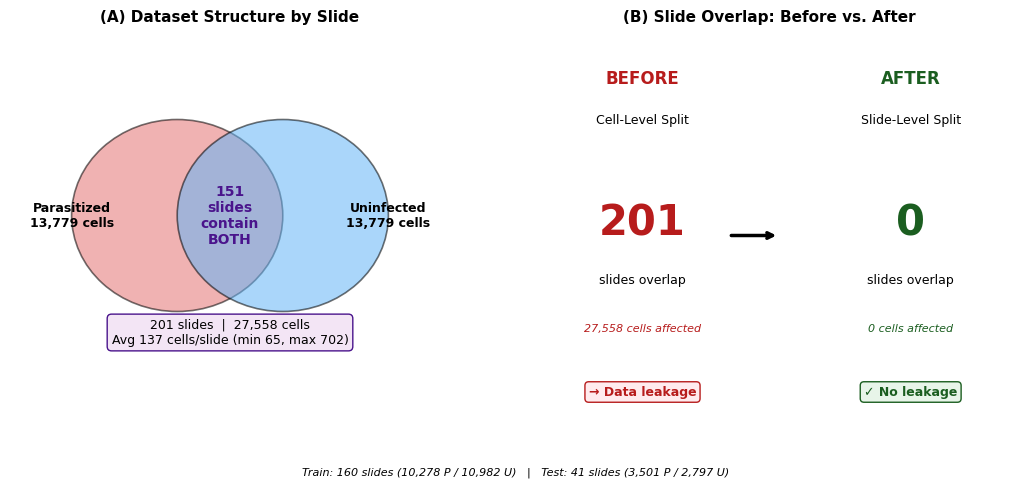

In [5]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

# ============================================================
# STEP 1: Load dataset
# ============================================================
base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
categories = ['Parasitized', 'Uninfected']

image_paths, labels = [], []
for cat_idx, cat in enumerate(categories):
    folder = os.path.join(base_path, cat)
    exts = ('.png', '.jpg', '.jpeg')
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.lower().endswith(exts)]
    image_paths.extend(files)
    labels.extend([cat_idx] * len(files))

# ============================================================
# STEP 2: Group cells by slide
# ============================================================
slide_to_cells  = defaultdict(list)
slide_to_labels = defaultdict(list)
for path, label in zip(image_paths, labels):
    sid = os.path.basename(path).split('_')[0]
    slide_to_cells[sid].append(path)
    slide_to_labels[sid].append(label)

n_total_cells  = len(image_paths)
n_total_slides = len(slide_to_cells)

# ============================================================
# STEP 3: Slide composition
# ============================================================
slide_majority = {}
for sid, labs in slide_to_labels.items():
    slide_majority[sid] = max(set(labs), key=labs.count)

n_parasitized_slides = sum(1 for v in slide_majority.values() if v == 0)
n_uninfected_slides  = sum(1 for v in slide_majority.values() if v == 1)

mixed_slides = sum(1 for labs in slide_to_labels.values() if len(set(labs)) > 1)
mixed_cells  = sum(len(labs) for labs in slide_to_labels.values() if len(set(labs)) > 1)
pure_slides  = n_total_slides - mixed_slides
pure_cells   = n_total_cells - mixed_cells

label_counts = Counter(labels)
n_parasitized_cells = label_counts[0]
n_uninfected_cells  = label_counts[1]

cells_per_slide = [len(v) for v in slide_to_cells.values()]
avg_cells = sum(cells_per_slide) / len(cells_per_slide)
min_cells = min(cells_per_slide)
max_cells = max(cells_per_slide)

# ============================================================
# STEP 4: Overlap under cell-level split
# ============================================================
train_cells, test_cells = train_test_split(
    image_paths, test_size=0.20, random_state=42, stratify=labels
)
train_slides_leaky = {os.path.basename(p).split('_')[0] for p in train_cells}
test_slides_leaky  = {os.path.basename(p).split('_')[0] for p in test_cells}
overlap_leaky = train_slides_leaky & test_slides_leaky
overlap_cells_leaky = sum(
    1 for p in image_paths
    if os.path.basename(p).split('_')[0] in overlap_leaky
)

# ============================================================
# STEP 5: Overlap under slide-level split
# ============================================================
unique_slides = list(slide_to_cells.keys())
slide_labels  = [slide_majority[s] for s in unique_slides]

train_s, test_s = train_test_split(
    unique_slides, test_size=0.20, random_state=42, stratify=slide_labels
)
train_slides_clean = set(train_s)
test_slides_clean  = set(test_s)
overlap_clean = train_slides_clean & test_slides_clean

# Split composition
path_to_label = dict(zip(image_paths, labels))
train_paths = [p for s in train_slides_clean for p in slide_to_cells[s]]
test_paths  = [p for s in test_slides_clean  for p in slide_to_cells[s]]
train_labels = [path_to_label[p] for p in train_paths]
test_labels  = [path_to_label[p] for p in test_paths]

train_parasitized = sum(1 for l in train_labels if l == 0)
train_uninfected  = sum(1 for l in train_labels if l == 1)
test_parasitized  = sum(1 for l in test_labels if l == 0)
test_uninfected   = sum(1 for l in test_labels if l == 1)

# ============================================================
# STEP 6: Print all numbers
# ============================================================
print("=" * 65)
print("DATASET SUMMARY")
print("=" * 65)
print(f"Total cells                    : {n_total_cells:,}")
print(f"  Parasitized                  : {n_parasitized_cells:,}")
print(f"  Uninfected                   : {n_uninfected_cells:,}")
print(f"Total slides                   : {n_total_slides}")
print(f"  Majority Parasitized         : {n_parasitized_slides}")
print(f"  Majority Uninfected          : {n_uninfected_slides}")
print(f"Mixed slides (both classes)    : {mixed_slides} "
      f"({mixed_slides/n_total_slides*100:.1f}%)")
print(f"Pure slides (single class)     : {pure_slides}")
print(f"Cells per slide (avg/min/max)  : {avg_cells:.1f} / {min_cells} / {max_cells}")
print()
print("LEAKAGE MEASUREMENT")
print("-" * 65)
print(f"Cell-level split overlap       : {len(overlap_leaky)} slides "
      f"({overlap_cells_leaky:,} cells)")
print(f"Slide-level split overlap      : {len(overlap_clean)} slides")
print()
print("SPLIT COMPOSITION (slide-level protocol)")
print("-" * 65)
print(f"Train: {len(train_slides_clean)} slides | "
      f"{train_parasitized:,} Parasitized | {train_uninfected:,} Uninfected")
print(f"Test : {len(test_slides_clean)} slides | "
      f"{test_parasitized:,} Parasitized | {test_uninfected:,} Uninfected")
print("=" * 65)

# ============================================================
# STEP 7: Plot
# ============================================================
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10})

fig = plt.figure(figsize=(11, 5))

# ---------- LEFT: Dataset composition (Venn-style) ----------
ax1 = fig.add_axes([0.04, 0.10, 0.40, 0.80])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('(A) Dataset Structure by Slide', fontsize=11,
              fontweight='bold', pad=10)

# Two overlapping circles
c_par   = Circle((3.8, 5.5), 2.4, color='#E57373', alpha=0.55,
                 ec='black', lw=1.2)
c_uninf = Circle((6.2, 5.5), 2.4, color='#64B5F6', alpha=0.55,
                 ec='black', lw=1.2)
ax1.add_patch(c_par)
ax1.add_patch(c_uninf)

ax1.text(1.4, 5.5, f'Parasitized\n{n_parasitized_cells:,} cells',
         ha='center', va='center', fontsize=9, fontweight='bold')
ax1.text(8.6, 5.5, f'Uninfected\n{n_uninfected_cells:,} cells',
         ha='center', va='center', fontsize=9, fontweight='bold')
ax1.text(5.0, 5.5,
         f'{mixed_slides}\nslides\ncontain\nBOTH',
         ha='center', va='center', fontsize=10,
         fontweight='bold', color='#4A148C')

ax1.text(5.0, 2.3,
         f'{n_total_slides} slides  |  {n_total_cells:,} cells\n'
         f'Avg {avg_cells:.0f} cells/slide (min {min_cells}, max {max_cells})',
         ha='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.35',
                   facecolor='#F3E5F5', edgecolor='#4A148C'))

# ---------- RIGHT: Before/After overlap ----------
ax2 = fig.add_axes([0.50, 0.10, 0.46, 0.80])
ax2.axis('off')
ax2.set_title('(B) Slide Overlap: Before vs. After',
              fontsize=11, fontweight='bold', pad=10)

# BEFORE
ax2.text(0.25, 0.88, 'BEFORE', ha='center', fontsize=12,
         fontweight='bold', color='#B71C1C', transform=ax2.transAxes)
ax2.text(0.25, 0.78, 'Cell-Level Split', ha='center', fontsize=9,
         transform=ax2.transAxes)
ax2.text(0.25, 0.50, f'{len(overlap_leaky)}',
         ha='center', fontsize=30, fontweight='bold',
         color='#B71C1C', transform=ax2.transAxes)
ax2.text(0.25, 0.38, 'slides overlap',
         ha='center', fontsize=9, transform=ax2.transAxes)
ax2.text(0.25, 0.26, f'{overlap_cells_leaky:,} cells affected',
         ha='center', fontsize=8, style='italic',
         color='#B71C1C', transform=ax2.transAxes)
ax2.text(0.25, 0.10, '→ Data leakage',
         ha='center', fontsize=9, fontweight='bold',
         color='#B71C1C', transform=ax2.transAxes,
         bbox=dict(boxstyle='round,pad=0.3',
                   facecolor='#FFEBEE', edgecolor='#B71C1C'))

# Arrow
ax2.annotate('', xy=(0.52, 0.5), xytext=(0.42, 0.5),
             xycoords='axes fraction',
             arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

# AFTER
ax2.text(0.78, 0.88, 'AFTER', ha='center', fontsize=12,
         fontweight='bold', color='#1B5E20', transform=ax2.transAxes)
ax2.text(0.78, 0.78, 'Slide-Level Split', ha='center', fontsize=9,
         transform=ax2.transAxes)
ax2.text(0.78, 0.50, f'{len(overlap_clean)}',
         ha='center', fontsize=30, fontweight='bold',
         color='#1B5E20', transform=ax2.transAxes)
ax2.text(0.78, 0.38, 'slides overlap',
         ha='center', fontsize=9, transform=ax2.transAxes)
ax2.text(0.78, 0.26, f'{0} cells affected',
         ha='center', fontsize=8, style='italic',
         color='#1B5E20', transform=ax2.transAxes)
ax2.text(0.78, 0.10, '✓ No leakage',
         ha='center', fontsize=9, fontweight='bold',
         color='#1B5E20', transform=ax2.transAxes,
         bbox=dict(boxstyle='round,pad=0.3',
                   facecolor='#E8F5E9', edgecolor='#1B5E20'))

# ---------- Bottom note ----------
fig.text(0.5, 0.02,
         f'Train: {len(train_slides_clean)} slides ({train_parasitized:,} P / {train_uninfected:,} U)   |   '
         f'Test: {len(test_slides_clean)} slides ({test_parasitized:,} P / {test_uninfected:,} U)',
         ha='center', fontsize=8, style='italic')

# ---------- Save ----------
plt.savefig('dataset_structure_and_leakage.pdf', dpi=300,
            bbox_inches='tight', format='pdf', facecolor='white')
plt.savefig('dataset_structure_and_leakage.png', dpi=300,
            bbox_inches='tight', format='png', facecolor='white')
print("\nSaved: dataset_structure_and_leakage.pdf / .png (300 DPI)")
plt.show()